In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Load Data and Models
data = np.load('../data/fashion_data_complete.npz')
X_test = data['X_test']
y_test = data['y_test']
class_names = data['class_names']
X_test_images = data['X_test_images'] # For qualitative view

# Load all 4 models
models = {
    "KNN": joblib.load('../models/knn_fashion_model.joblib'),
    "Naive Bayes": joblib.load('../models/nb_fashion_model.joblib'),
}



In [7]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(df_results)
# SCREENSHOT: Include this table in your report.

         Model  Accuracy
0          KNN    0.8581
1  Naive Bayes    0.5705


In [4]:
# 2. QUANTITATIVE ANALYSIS: Comparison Table
results = []
all_preds = {}

for name, model in models.items():
    preds = model.predict(X_test)
    all_preds[name] = preds
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("--- Model Comparison Table ---")
print(df_results)



--- Model Comparison Table ---
         Model  Accuracy  F1-Score
0          KNN    0.8581  0.857785
1  Naive Bayes    0.5705  0.540289


In [9]:
from sklearn.metrics import classification_report

print("--- Detailed Analysis: Best Model (KNN) ---")
print(classification_report(y_test, all_preds['KNN'], target_names=class_names))

--- Detailed Analysis: Best Model (KNN) ---
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.88      0.82      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.75      0.78      0.77      1000
       Dress       0.91      0.88      0.89      1000
        Coat       0.79      0.79      0.79      1000
      Sandal       0.98      0.83      0.90      1000
       Shirt       0.67      0.61      0.64      1000
     Sneaker       0.88      0.94      0.91      1000
         Bag       0.98      0.94      0.96      1000
  Ankle boot       0.89      0.96      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



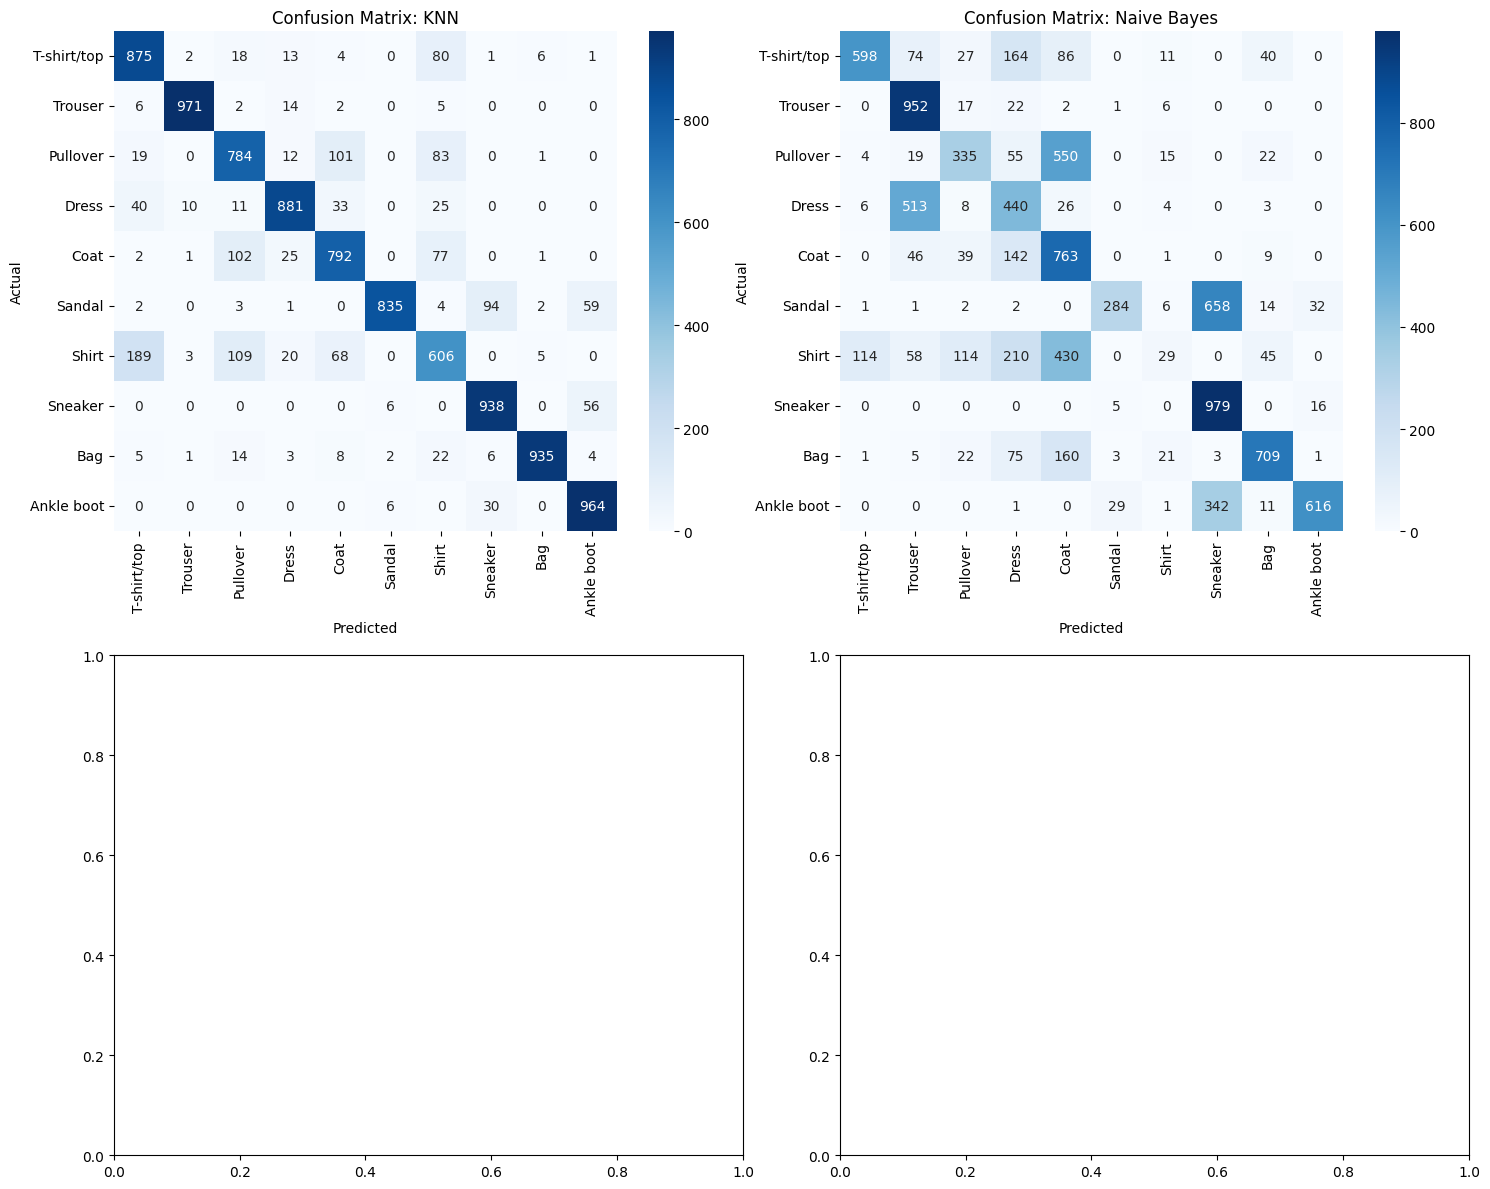

In [5]:
# 3. VISUALIZATION: Confusion Matrices (Requirement 4.4)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, (name, preds) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()




Comparing Best (KNN) vs Worst (Naive Bayes) qualitatively:


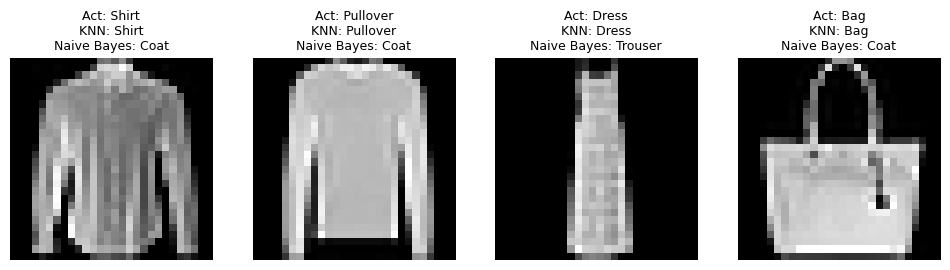

In [6]:
# 4. QUALITATIVE ANALYSIS: Error Analysis (Requirement 4.4)
# Let's find an image where KNN (likely best) succeeded but NB failed
best_model_name = df_results.iloc[0]['Model']
worst_model_name = df_results.iloc[-1]['Model']

print(f"\nComparing Best ({best_model_name}) vs Worst ({worst_model_name}) qualitatively:")

plt.figure(figsize=(12, 5))
for i in range(4):
    idx = np.random.randint(0, len(X_test))
    plt.subplot(1, 4, i+1)
    plt.imshow(X_test_images[idx], cmap='gray')
    
    p_best = class_names[all_preds[best_model_name][idx]]
    p_worst = class_names[all_preds[worst_model_name][idx]]
    actual = class_names[y_test[idx]]
    
    plt.title(f"Act: {actual}\n{best_model_name}: {p_best}\n{worst_model_name}: {p_worst}", fontsize=9)
    plt.axis('off')
plt.show()